# Classical Multivariate Visualization: Wine Dataset

This notebook applies five classical multivariate visualization techniques to the Wine dataset.

**Target variable:** `target` (wine class)

### Methods covered:
1. Enhanced Scatterplot
2. Pairplot with hue
3. FacetGrid / Catplot (binned alcohol)
4. Parallel Coordinates
5. Optional: 3D Scatterplot (not interactive here)

## 1. Enhanced Scatterplot

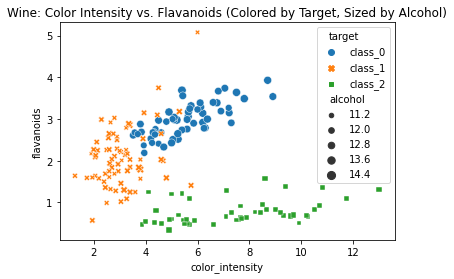

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Load dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
df_wine['target'] = df_wine['target'].map(dict(enumerate(wine.target_names)))

# Plot
sns.scatterplot(data=df_wine, x='color_intensity', y='flavanoids', hue='target', size='alcohol', style='target')
plt.title('Wine: Color Intensity vs. Flavanoids (Colored by Target, Sized by Alcohol)')
plt.show()

## 2. Pairplot with Hue

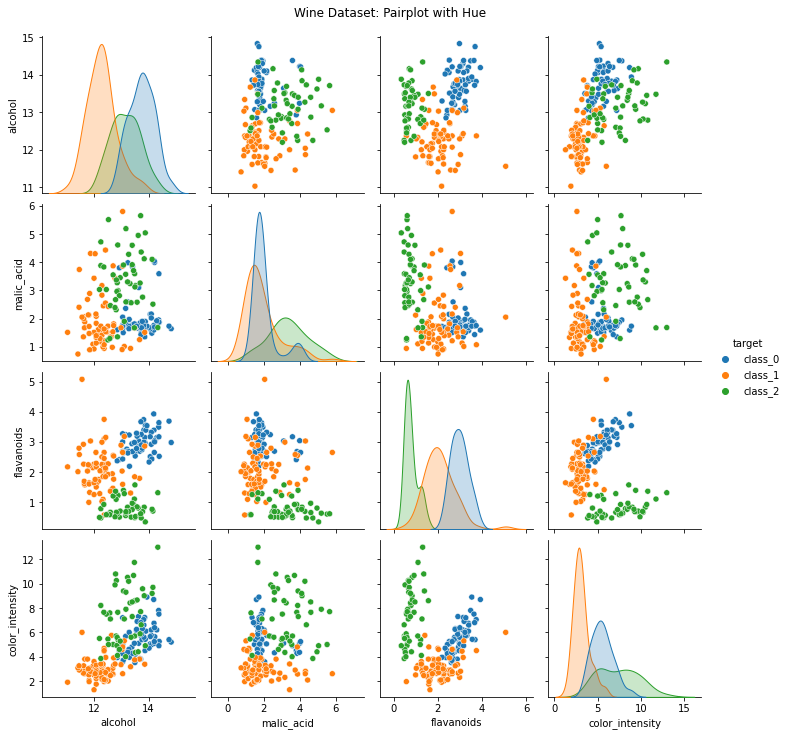

In [2]:
selected_features = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity', 'target']
sns.pairplot(df_wine[selected_features], hue='target')
plt.suptitle('Wine Dataset: Pairplot with Hue', y=1.02)
plt.show()

## 3. Faceted Boxplot by Alcohol Bin and Target

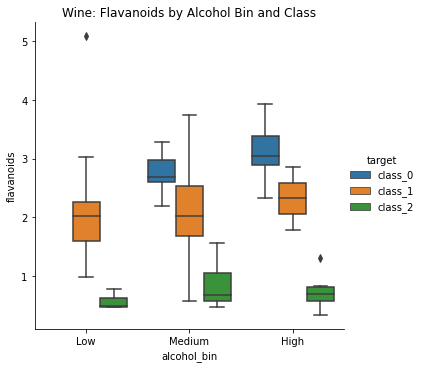

In [3]:
df_wine['alcohol_bin'] = pd.cut(df_wine['alcohol'], bins=3, labels=['Low', 'Medium', 'High'])
sns.catplot(data=df_wine, x='alcohol_bin', y='flavanoids', hue='target', kind='box')
plt.title('Wine: Flavanoids by Alcohol Bin and Class')
plt.show()

## 4. Parallel Coordinates

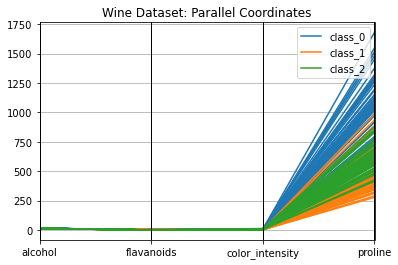

In [4]:
from pandas.plotting import parallel_coordinates

subset = df_wine[['alcohol', 'flavanoids', 'color_intensity', 'proline', 'target']]
parallel_coordinates(subset, class_column='target', color=('#1f77b4', '#ff7f0e', '#2ca02c'))
plt.title('Wine Dataset: Parallel Coordinates')
plt.show()